In [30]:
# 데이터 로드
import seaborn as sns

row_tips = sns.load_dataset('tips')

In [31]:
# 데이터 전처리 및 저장

## 1. 데이터 탐색
# row_tips.info() # sex, smoker, day, time 컬럼이 category 임을 확인
row_tips.head() # sex, smoker, day, time 데이터 생김새 확인
# row_tips['time'].value_counts() # 어떤 데이터가 있는지 확인(Dinner, Lunch)

## 2. 데이터 변경
row_tips['sex'] = row_tips['sex'].map({'Female':0, 'Male':1})
row_tips['smoker'] = row_tips['smoker'].map({'No':0, 'Yes':1})
row_tips['time'] = row_tips['time'].map({'Lunch':0, 'Dinner':1})

## 3. Feature Engineering
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
row_tips['day'] = le.fit_transform(row_tips['day'])
row_tips.head()

## 4. 데이터 저장
row_tips.to_csv('tips2.csv', index=False)

In [32]:
# 변형 데이터 호출
import pandas as pd
tips = pd.read_csv('tips2.csv')
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,0,0,2,1,2
1,10.34,1.66,1,0,2,1,3
2,21.01,3.50,1,0,2,1,3
3,23.68,3.31,1,0,2,1,2
4,24.59,3.61,0,0,2,1,4
...,...,...,...,...,...,...,...
239,29.03,5.92,1,0,1,1,3
240,27.18,2.00,0,1,1,1,2
241,22.67,2.00,1,1,1,1,2
242,17.82,1.75,1,0,1,1,2


In [ ]:
# 데이터 탐색(생략, 이미 본 데이터)

In [ ]:
# 데이터 분석(생략)

In [ ]:
# 딥러닝 모델링 - 학습 데이터, 평가 데이터 구분하기
    # 지도학습의 경우, 정답 필요
    # x, y 데이터를 갖고 모델 학습하고 검증할 수 있는 학습 및 평가 데이터셋으로 구분 필요
    # y(레이블) 값으로 회귀, 분류 구별 가능
        # 예시: 학점, 남녀, 1~9 등급 등 -> 범주형 데이터이므로 분류 모델
        # 예시: 삼성전자 주가, 습도/온도, 유가 동향 등 -> 연속형 데이터이므로 회귀 모델

# "회귀 모델"로 가정
    # 연속형 데이터 탐색하기
tips.info() # total_bill, tip 칼럼의 경우 연속형 데이터임을 확인

# x, y 데이터 설정
y = tips[['tip']]
x = tips.drop(columns='tip')

# x, y로 학습 및 평가 데이터셋 만들기
    # 학습:평가 = 8:2
    # 재현 가능함을 고려할 것
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

x_train = x_train.values
x_test = x_test.values
y_train = y_train.values
y_test = y_test.values

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    int64  
 3   smoker      244 non-null    int64  
 4   day         244 non-null    int64  
 5   time        244 non-null    int64  
 6   size        244 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 13.5 KB


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 4)              │            28 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53 (212.00 B)

 Trainable params: 53 (212.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.1332 - mae: 1.0791
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.7331 - mae: 0.9787
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.6197 - mae: 0.9699
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6147 - mae: 0.9487
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.5683 - mae: 0.9408
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.5676 - mae: 0.9393
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.5468 - mae: 0.9215
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.5344 - mae: 0.9311
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.4762 - mae: 0.9111
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.4696 - mae: 0.9079
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.4587 - mae: 0.8943 - val_loss: 0.9215 - val_mae: 0.7793
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.4301 - mae: 0.8902 - val_lo

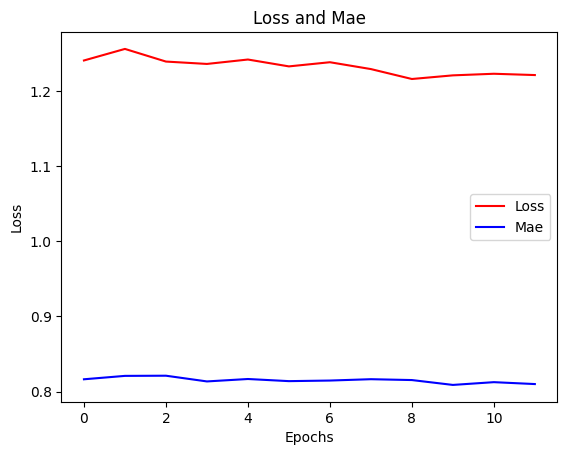

In [56]:
# (회귀) 딥러닝 모델링 - 딥러닝 모델링
    # 아웃풋 노드 1개일 경우, activation=None (혹은 linear)
    # Loss 함수: mse, mae

## 1. 라이브러리 호출하기 #######################################
import tensorflow as tf # tensorflow 가져오기
from tensorflow.keras.models import Sequential # 도화지
from tensorflow.keras.layers import Dense # 히든/아웃풋 레이어
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
# EarlyStopping: callback으로 매 학습마다 성능을 측정하고 성능이 더 나아지지 않으면 조기 종료
# ModelCheckpoint: 주로 성능이 제일 좋을 때 모델을 저장하기 위해 사용

## 2. 도화지 정의 #######################################
model = Sequential()

## 3. 레이어 생성 #######################################
# 1. 첫 번째 히든 레이어 생성
model.add(Dense(4, activation='relu', input_shape=(6,))) # ⭐️ input_shape 반드시 추가. (6,)은 6개의 features인 1차원 행렬을 의미
# 6인 이유: x_train.shape으로 컬럼이 6개임. 반드시 컬럼 수와 일치시켜야 함. ⭐️
# (6,)과 (6,1)은 다른 의미, 1차원과 2차원의 차이

# 2. 두 번째 히든 레이어 생성
model.add(Dense(4, activation='relu'))

# 3. 아웃풋 레이어 생성
model.add(Dense(1, activation=None))
model.summary() # 결과 확인

## 4. 성능 향상 ⭐️ #######################################
    # 회귀 모델: mse
    # 최적화 알고리즘: adam
    # 모델 성능 측정: mae
model.compile(loss='mse', optimizer='adam', metrics=['mae'])

## 5. 학습 실행 #######################################
# 1. 최초 학습
    # 학습 횟수: 10
    # 쪼갤 학습: 8
    # history에 저장
history = model.fit(x_train, y_train, epochs=10, batch_size=8)

# 2. 재학습
    # 학습 횟수: 50
    # 쪼갤 학습: 8
    # 학습 검증: x_test, y_test 사용
    # history에 저장
history = model.fit(x_train, y_train, epochs=50, batch_size=8, validation_data=(x_test, y_test))

# 3. 조기종료 기능 추가 후 재학습
es = EarlyStopping(patience=3, verbose=1) # 매 epoch마다 val_loss(default)를 측정해서, 3번 동안 성능이 더 나아지지 않으면 조기 종료
mc = ModelCheckpoint(
        filepath='best_model.keras',
        save_best_only=True,
        verbose=1
    ) # 매 epoch마다 val_loss(default)를 측정해서, 이전보다 성능이 좋아지면 해당 모델을 저장
history = model.fit(x_train, y_train, epochs=50, batch_size=8, validation_data=(x_test, y_test), callbacks=[es, mc])

## 6. 모델 예측 #######################################
    # 0 라인 샘플 데이터를 모델로 입력해서 예측하기
pred = model.predict(x_test[0:2])
print(pred)

## 7. 결과 시각화 #######################################
    # history의 loss, mae 그래프 그리기
import matplotlib.pyplot as plt

history_loss = history.history['loss']
history_mae = history.history['mae']
plt.figure()
plt.plot(history_loss, 'r')
plt.plot(history_mae, 'b')
plt.title('Loss and Mae')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Loss', 'Mae'])
plt.show()

In [57]:
# 딥러닝 모델링 - 학습 데이터, 평가 데이터 구분하기
    # 지도학습의 경우, 정답 필요
    # x, y 데이터를 갖고 모델 학습하고 검증할 수 있는 학습 및 평가 데이터셋으로 구분 필요
    # y(레이블) 값으로 회귀, 분류 구별 가능
        # 예시: 학점, 남녀, 1~9 등급 등 -> 범주형 데이터이므로 분류 모델
        # 예시: 삼성전자 주가, 습도/온도, 유가 동향 등 -> 연속형 데이터이므로 회귀 모델

# "분류 모델"로 가정
    # 범주형 데이터 탐색하기
tips.info() # total_bill, tip 칼럼의 경우 연속형 데이터임을 확인

# x, y 데이터 설정
y = tips[['day']]
x = tips.drop(columns='day')

# x, y로 학습 및 평가 데이터셋 만들기
    # 학습:평가 = 8:2
    # 재현 가능함을 고려할 것
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

x_train = x_train.values
x_test = x_test.values
y_train = y_train.values
y_test = y_test.values

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    int64  
 3   smoker      244 non-null    int64  
 4   day         244 non-null    int64  
 5   time        244 non-null    int64  
 6   size        244 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 13.5 KB


(195, 6)
[0 1 2 3]


Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_55 (Dense)                │ (None, 10)             │            70 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 4)              │            44 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 224 (896.00 B)

 Trainable params: 224 (896.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.3538 - loss: 5.9795
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2667 - loss: 2.8312
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2410 - loss: 1.6585
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3179 - loss: 1.5747
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2974 - loss: 1.5269
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3026 - loss: 1.5246
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3026 - loss: 1.4792
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3333 - loss: 1.4809
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3128 - loss: 1.4540
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3128 - loss: 1.4289
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3231 - loss: 1.4110
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy:

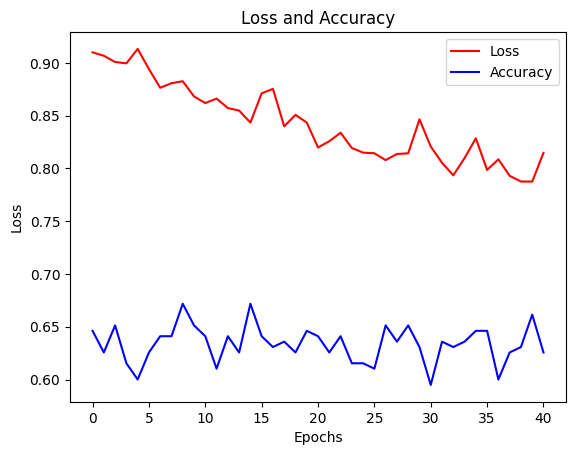

In [ ]:
# (분류) 딥러닝 모델링 - 딥러닝 모델링
    # 아웃풋 노드 1개일 경우, activation='sigmoid'
    # 아웃풋 노드 n개일 경우, activation='softmax'
    # Loss 함수: 아웃풋 노드 1개일 경우, binary_crossentropy
    # Loss 함수: 아웃풋 노드 n개일 경우, sparse_categorical_crossentropy
        # y값을 원핫인코딩 했을 경우, categorical_crossentropy
        # y값을 원핫인코딩 안했을 경우, sparse_categorical_crossentropy (내부적으로 원핫인코딩 수행)

## 1. 라이브러리 호출하기 #######################################
import tensorflow as tf # tensorflow 가져오기
from tensorflow.keras.models import Sequential # 도화지
from tensorflow.keras.layers import Dense # 히든/아웃풋 레이어
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import numpy as np
# EarlyStopping: callback으로 매 학습마다 성능을 측정하고 성능이 더 나아지지 않으면 조기 종료
# ModelCheckpoint: 주로 성능이 제일 좋을 때 모델을 저장하기 위해 사용

## 2. 도화지 정의 #######################################
model = Sequential()

print(x_train.shape)
print(np.unique(y_train))

## 3. 레이어 생성 #######################################
# 1. 첫 번째 히든 레이어 생성
model.add(Dense(10, activation='relu', input_shape=(6,))) # ⭐️ input_shape 반드시 추가. (6,)은 6개의 features인 1차원 행렬을 의미
# 6인 이유: x_train.shape으로 컬럼이 6개임. 반드시 컬럼 수와 일치시켜야 함. ⭐️
# (6,)과 (6,1)은 다른 의미, 1차원과 2차원의 차이

# 2. 두 번째 히든 레이어 생성
model.add(Dense(10, activation='relu'))

# 3. 아웃풋 레이어 생성 ⭐️
    # 다중 분류 모델이고 아웃풋 동그라미가 4개 이므로 softmax 함수 지정
model.add(Dense(4, activation='softmax'))
model.summary() # 결과 확인

## 4. 성능 향상 ⭐️ #######################################
    # 회귀 모델: sparse_categorical_crossentropy (4개의 아웃풋 동그라미가 4개이므로)
    # 최적화 알고리즘: adam
    # 모델 성능 측정: accuracy
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

## 5. 학습 실행 #######################################
# 1. 최초 학습
    # 학습 횟수: 20
    # 쪼갤 학습: 8
    # history에 저장
history = model.fit(x_train, y_train, epochs=20, batch_size=8)

# 2. 재학습
    # 학습 횟수: 50
    # 쪼갤 학습: 8
    # 학습 검증: x_test, y_test 사용
    # history에 저장
history = model.fit(x_train, y_train, epochs=50, batch_size=8, validation_data=(x_test, y_test))

# 3. 조기종료 기능 추가 후 재학습
es = EarlyStopping(patience=3, verbose=1) # 매 epoch마다 val_loss(default)를 측정해서, 3번 동안 성능이 더 나아지지 않으면 조기 종료
mc = ModelCheckpoint(
        filepath='best_model.keras',
        save_best_only=True,
        verbose=1
    ) # 매 epoch마다 val_loss(default)를 측정해서, 이전보다 성능이 좋아지면 해당 모델을 저장
history = model.fit(x_train, y_train, epochs=50, batch_size=8, validation_data=(x_test, y_test), callbacks=[es, mc])

## 6. 모델 예측 #######################################
    # 0 라인 샘플 데이터를 모델로 입력해서 예측하기
pred = model.predict(x_test[0:2])
print(pred)

np.argmax(pred, axis=1) # pred 결과에 대한 분류값 출력

## 7. 결과 시각화 #######################################
    # history의 loss, mae 그래프 그리기
import matplotlib.pyplot as plt

history_loss = history.history['loss']
history_mae = history.history['accuracy']
plt.figure()
plt.plot(history_loss, 'r')
plt.plot(history_mae, 'b')
plt.title('Loss and Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Loss', 'Accuracy'])
plt.show()